# Tarea 3

Somos el equipo 5, conformados por:
  - Raúl Llamosas Alvarado
  - Eumir Rendon Uresti
  - Gabriela Peña Franco
  - Daniela Ibarra Gatica
  - Randy Jesús García Mejía
  - Daniela Vázquez Sánchez



Vamos a usar una base de datos de rentas de bicicletas por hora `Bike Sharing Demand` disponible en Scikit-learn. Tenemos datos de la forma

$$(x_t, y_t),$$

donde $x_t$ es un vector de características, $y_t$ el número de bicicletas rentadas al tiempo $t$. Aplicar el algoritmo *Online Gradient Descent* a esta base de datos y evaluar su Regret.

1. Descripción del problema
2. Metodología
3. Resultados, tablas, gráficas
4. Conclusiones

### Descripción del problema


El problema abordado en este trabajo consiste en predecir la demanda horaria de bicicletas en el sistema de alquiler compartido "Bike Sharing" de la ciudad de Washington D.C.
El objetivo es implementar el algoritmo Online Gradient Descent (OGD) para actualizar los parámetros de un modelo de regresión lineal de manera secuencial, a medida que se observan nuevos ejemplos

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

bike_sharing = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True)
bike_sharing.frame.head(5)

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


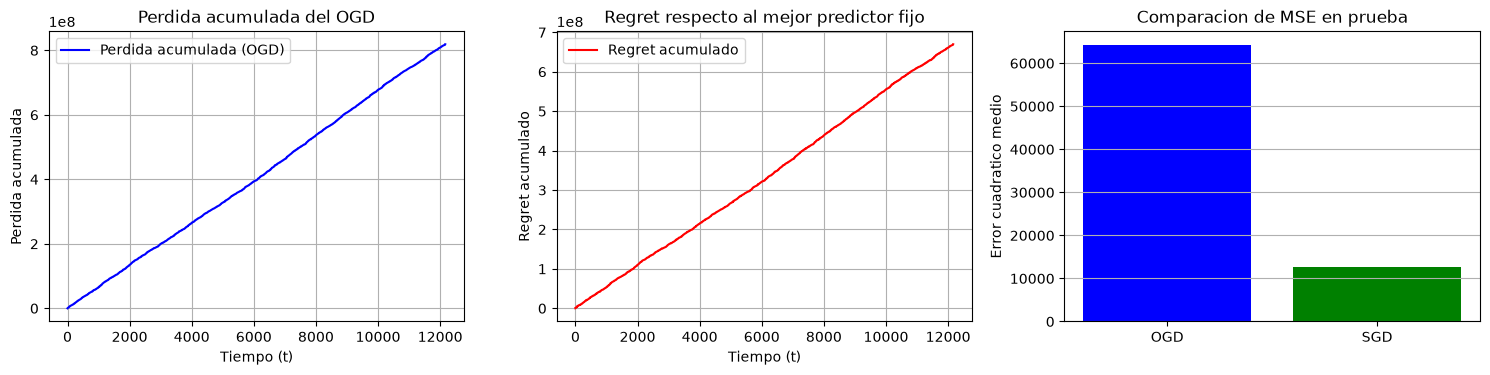

MSE en prueba con OGD: 64262.0151
MSE en prueba con SGD (scikit-learn): 12638.1773


In [25]:

df = bike_sharing.frame

columnas_numericas = ['temp', 'feel_temp', 'humidity', 'windspeed']
columnas_categoricas = ['season', 'weather', 'weekday', 'month', 'hour']
columnas_binarias = ['year', 'holiday', 'workingday']

preprocesador = ColumnTransformer([
    ('num', StandardScaler(), columnas_numericas),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), columnas_categoricas)
])

X = df[columnas_numericas + columnas_categoricas + columnas_binarias]
y = df['count'].values

X_entrada, X_prueba, y_entrada, y_prueba = train_test_split(
    X, y, test_size=0.3, random_state=42
)

pipeline = Pipeline([
    ('preprocesador', preprocesador)
])

pipeline.fit(X_entrada)
X_entrada_proc = pipeline.transform(X_entrada)
X_prueba_proc = pipeline.transform(X_prueba)

num_caracteristicas = X_entrada_proc.shape[1]

n = len(X_entrada_proc)
w_ogd = np.zeros(num_caracteristicas)
tasa_aprendizaje = 0.01

perdidas_online = []
perdidas_acumuladas = []
regret_acumulado = []

for t in range(n):
    x_t = X_entrada_proc[t]
    y_t = y_entrada[t]
    
    pred_t = np.dot(w_ogd, x_t)
    
    error_t = pred_t - y_t
    perdida_t = error_t ** 2
    perdidas_online.append(perdida_t)
    perdidas_acumuladas.append(np.sum(perdidas_online))
    
    if t > 0:
        X_prefix = X_entrada_proc[:t+1]
        y_prefix = y_entrada[:t+1]
        
        w_lstsq, _, _, _ = np.linalg.lstsq(X_prefix, y_prefix, rcond=None)
        
        pred_fijo = np.dot(X_prefix, w_lstsq)
        perdida_fijo = np.mean((pred_fijo - y_prefix) ** 2)
        
        regret_t = perdidas_acumuladas[-1] - perdida_fijo * (t + 1)
        regret_acumulado.append(regret_t)
    
    gradiente = 2 * error_t * x_t
    w_ogd = w_ogd - tasa_aprendizaje * gradiente
    
    norma_w = np.linalg.norm(w_ogd)
    if norma_w > 10.0:
        w_ogd = 10.0 * w_ogd / norma_w

x_prueba_proc = pipeline.transform(X_prueba)
predicciones_test = np.dot(x_prueba_proc, w_ogd)
mse_test_ogd = mean_squared_error(y_prueba, predicciones_test)

sgd = SGDRegressor(
    loss='squared_error',
    penalty=None,
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    random_state=42
)

sgd.fit(X_entrada_proc, y_entrada)
predicciones_sgd = sgd.predict(X_prueba_proc)
mse_test_sgd = mean_squared_error(y_prueba, predicciones_sgd)

fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

ejes[0].plot(perdidas_acumuladas, label='Perdida acumulada (OGD)', color='blue')
ejes[0].set_xlabel('Tiempo (t)')
ejes[0].set_ylabel('Perdida acumulada')
ejes[0].set_title('Perdida acumulada del OGD')
ejes[0].grid(True)
ejes[0].legend()

ejes[1].plot(regret_acumulado, label='Regret acumulado', color='red')
ejes[1].set_xlabel('Tiempo (t)')
ejes[1].set_ylabel('Regret acumulado')
ejes[1].set_title('Regret respecto al mejor predictor fijo')
ejes[1].grid(True)
ejes[1].legend()

ejes[2].bar(['OGD', 'SGD'], [mse_test_ogd, mse_test_sgd], color=['blue', 'green'])
ejes[2].set_ylabel('Error cuadratico medio')
ejes[2].set_title('Comparacion de MSE en prueba')
ejes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"MSE en prueba con OGD: {mse_test_ogd:.4f}")
print(f"MSE en prueba con SGD (scikit-learn): {mse_test_sgd:.4f}")